# Dataset generation

| Var             | Range | Unit | Description                             |
|-----------------|-------|------|-----------------------------------------|
| $\eta_{PV}$     | 5-20  |      | panel efficiency                        |
| $\eta_{UGC}$    | 80-95 |      | PMU efficiency                          |
| $\eta_{B}$      | 80-90 |      | battery efficiency                      |
| $\eta_{STC}$    | 19-22 | %    | nominal efficiency of energy conversion |
| $A_{\text{PV}}$ |       | m²   | photovoltaic panel surface              |
| Ppv             |       | W    | panel power output                      |
| G(h)            |       | W/m² | hourly solar irradiance                 |
| Pn              |       | W    | power demand                            |
| Ppmu            |       | W    | PMU power                               |
| Pb              |       | W    | battery power                           |


In [28]:
import itertools
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

## Generación de paneles

In [29]:
Apv = [i * 0.01 for i in range(1, 101)]  # 1 to 100 dm²
eta_stc = [x / 10 for x in range(190, 221, 5)]  # 19% to 22% (step: 0.5)

In [30]:
# generar todos los paneles

panels = list(itertools.product(Apv, eta_stc))
panels_df = pd.DataFrame(panels, columns=['Apv(m2)', 'eta_stc(%)'])
panels_df['Panel_ID'] = range(0, len(panels_df))
panels_df = panels_df[['Panel_ID', 'Apv(m2)', 'eta_stc(%)']]

print(f"# paneles posibles: {len(Apv)} × {len(eta_stc)} = {len(panels_df):,}")
print("Los 10 primeros:")
display(panels_df.head(10))


# paneles posibles: 100 × 7 = 700
Los 10 primeros:


,Panel_ID,Apv(m2),eta_stc(%)
0,0,0.01,19.0
1,1,0.01,19.5
2,2,0.01,20.0
3,3,0.01,20.5
4,4,0.01,21.0
5,5,0.01,21.5
6,6,0.01,22.0
7,7,0.02,19.0
8,8,0.02,19.5
9,9,0.02,20.0


## Datos de irradiancia

Cargar datos de irradiancia desde archivo CSV con datos horarios de todo el año.

In [31]:
try:
    # Columnas: Mes, Día, Hora, G(h), Temperatura
    data = pd.read_csv('data.csv', usecols=[1, 2, 3, 4, 5])

    print("📊 DATOS DE IRRADIANCIA")
    print(f"Total de registros: {len(data):,}")
    print(f"Columnas disponibles: {list(data.columns)}")
    print(f"Forma del dataset: {data.shape}")
    print(f"Meses: {data.iloc[:, 0].min()} - {data.iloc[:, 0].max()}")
    print(f"Días: {data.iloc[:, 1].min()} - {data.iloc[:, 1].max()}")

    # Mostrar estadísticas básicas de G(h)
    gh_column = data.columns[3]  # Cuarta columna: G(h)
    print(f"\n🌞 ESTADÍSTICAS DE IRRADIANCIA G(h):")
    print(f"Mínimo: {data[gh_column].min():.2f} W/m²")
    print(f"Máximo: {data[gh_column].max():.2f} W/m²")
    print(f"Promedio: {data[gh_column].mean():.2f} W/m²")
    print(f"Registros con G(h) > 0: {(data[gh_column] > 0).sum():,}")

    print(f"\n🔍 PRIMERAS 5 FILAS:")
    display(data.head())

    print(f"\n📊 INFORMACIÓN DE COLUMNAS:")
    display(data.info())
except FileNotFoundError:
    print("❌ Error: No se encontró el archivo 'data.csv'")
    print("Asegúrate de que el archivo esté en el directorio de trabajo actual")
except Exception as e:
    print(f"❌ Error al cargar el archivo: {e}")

📊 DATOS DE IRRADIANCIA
Total de registros: 8,760
Columnas disponibles: ['Mes', 'Día', 'Hora', 'G(h) - W/m2', 'Temperatura (°C)']
Forma del dataset: (8760, 5)
Meses: 1 - 12
Días: 1 - 31

🌞 ESTADÍSTICAS DE IRRADIANCIA G(h):
Mínimo: 0.00 W/m²
Máximo: 1045.00 W/m²
Promedio: 184.93 W/m²
Registros con G(h) > 0: 4,400

🔍 PRIMERAS 5 FILAS:


,Mes,Día,Hora,G(h) - W/m2,Temperatura (°C)
0,1,1,0,0,5.47
1,1,1,1,0,4.94
2,1,1,2,0,4.40
3,1,1,3,0,3.87
4,1,1,4,0,3.34



📊 INFORMACIÓN DE COLUMNAS:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Mes               8760 non-null   int64  
 1   Día               8760 non-null   int64  
 2   Hora              8760 non-null   int64  
 3   G(h) - W/m2       8760 non-null   int64  
 4   Temperatura (°C)  8760 non-null   float64
dtypes: float64(1), int64(4)
memory usage: 342.3 KB


None

## Cálculo de potencia

In [32]:
def panel_power(Gh, Apv, nstc):
    return Gh * Apv * nstc

In [33]:
def get_irradiance(day, hour):
    if not (1 <= day <= 31 and 0 <= hour <= 23):
        return None

    row = data[(data['Día'] == day) & (data['Hora'] == hour)]
    if row.empty:
        return None

    gh_column = data.columns[3]  # G(h) - W/m2
    return row.iloc[0][gh_column]

In [34]:
# Calcular la potencia de cada panel para cada valor de irradiancia

panel_powers = []
for idx, panel in panels_df.iterrows():
    Apv = panel['Apv(m2)']
    nstc = panel['eta_stc(%)'] / 100  # convertir a fracción

    powers = []
    for Gh in data[data.columns[3]]:
        powers.append(panel_power(Gh, Apv, nstc))
    panel_powers.append(powers)

panel_powers = pd.DataFrame(panel_powers)
panel_powers.index = panels_df['Panel_ID']
panel_powers.columns = [f"Gh_{i}" for i in range(len(panel_powers.columns))]

print("Potencia calculada para todos los paneles y todas las irradiancias.")
display(panel_powers.head())

Potencia calculada para todos los paneles y todas las irradiancias.


,Gh_0,Gh_1,Gh_2,Gh_3,Gh_4,Gh_5,Gh_6,Gh_7,Gh_8,Gh_9,...,Gh_8750,Gh_8751,Gh_8752,Gh_8753,Gh_8754,Gh_8755,Gh_8756,Gh_8757,Gh_8758,Gh_8759
Panel_ID,,,,,,,,,,,,,,,,,,,,,
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11590,0.4218,...,0.7106,0.4218,0.14250,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.11895,0.4329,...,0.7293,0.4329,0.14625,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.12200,0.4440,...,0.7480,0.4440,0.15000,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.12505,0.4551,...,0.7667,0.4551,0.15375,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.12810,0.4662,...,0.7854,0.4662,0.15750,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
# Calcular la energía total generada por cada panel a lo largo de todo el año (Wh)
# La energía por hora es igual a la potencia por hora (Wh)
energia_total_panel = panel_powers.sum(axis=1)
paneles_con_energia = panels_df.copy()
paneles_con_energia['Energia_total_Wh'] = energia_total_panel
print("Energía total generada por cada panel en todo el año (Wh):")
display(paneles_con_energia[['Panel_ID', 'Apv(m2)', 'eta_stc(%)', 'Energia_total_Wh']].head())

Energía total generada por cada panel en todo el año (Wh):


,Panel_ID,Apv(m2),eta_stc(%),Energia_total_Wh
0,0,0.01,19.0,3078.038
1,1,0.01,19.5,3159.039
2,2,0.01,20.0,3240.040
3,3,0.01,20.5,3321.041
4,4,0.01,21.0,3402.042


In [42]:
# Calculate daily energy generated by each panel (Wh/day)
num_days = len(panel_powers.columns) // 24
day_labels = [f"day_{(i//24+1):03d}" for i in range(len(panel_powers.columns))]
panel_daily_energy = panel_powers.copy()
panel_daily_energy.columns = day_labels
panel_daily_energy = panel_daily_energy.T.groupby(level=0).sum().T
panel_daily_energy.index = panels_df['Panel_ID']
print("Daily energy generated by each panel (Wh/day):")
display(panel_daily_energy.head())

Daily energy generated by each panel (Wh/day):


,day_001,day_002,day_003,day_004,day_005,day_006,day_007,day_008,day_009,day_010,...,day_356,day_357,day_358,day_359,day_360,day_361,day_362,day_363,day_364,day_365
Panel_ID,,,,,,,,,,,,,,,,,,,,,
0,3.70310,4.6094,4.62270,2.3218,3.19010,4.522,1.3034,1.19130,1.71950,5.56130,...,5.28010,3.7278,1.73850,2.2838,3.6632,2.55930,4.3472,5.51950,4.3586,3.26230
1,3.80055,4.7307,4.74435,2.3829,3.27405,4.641,1.3377,1.22265,1.76475,5.70765,...,5.41905,3.8259,1.78425,2.3439,3.7596,2.62665,4.4616,5.66475,4.4733,3.34815
2,3.89800,4.8520,4.86600,2.4440,3.35800,4.760,1.3720,1.25400,1.81000,5.85400,...,5.55800,3.9240,1.83000,2.4040,3.8560,2.69400,4.5760,5.81000,4.5880,3.43400
3,3.99545,4.9733,4.98765,2.5051,3.44195,4.879,1.4063,1.28535,1.85525,6.00035,...,5.69695,4.0221,1.87575,2.4641,3.9524,2.76135,4.6904,5.95525,4.7027,3.51985
4,4.09290,5.0946,5.10930,2.5662,3.52590,4.998,1.4406,1.31670,1.90050,6.14670,...,5.83590,4.1202,1.92150,2.5242,4.0488,2.82870,4.8048,6.10050,4.8174,3.60570


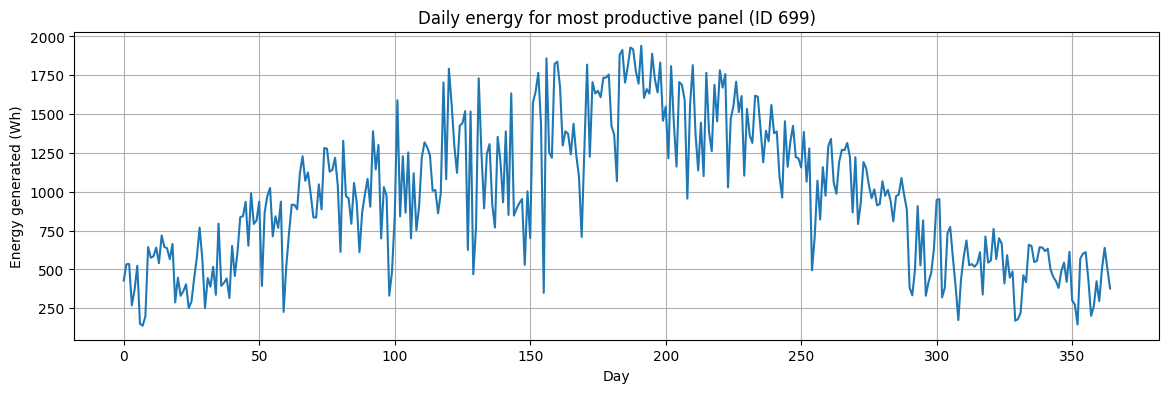

In [43]:
# Plot daily energy for the most productive panel
most_productive_panel_id = panel_daily_energy.sum(axis=1).idxmax()
energy_per_day = panel_daily_energy.loc[most_productive_panel_id]
plt.figure(figsize=(14,4))
plt.plot(energy_per_day.values)
plt.title(f"Daily energy for most productive panel (ID {most_productive_panel_id})")
plt.xlabel("Day")
plt.ylabel("Energy generated (Wh)")
plt.grid(True)
plt.show()